# Tier 2: CNN + BiLSTM for Slavic Language Identification

## What this notebook does
- Loads pre-extracted 80-band log-Mel spectrograms from cache (Drive / Kaggle Dataset)
- Feeds them through a CNN feature extractor → 2-layer BiLSTM → mean pooling
- Trains with CrossEntropy loss and SpecAugment data augmentation
- Evaluates per-language accuracy, confusion matrix, t-SNE embeddings
- Compares directly against the Tier 1 MelCNN baseline

## Architecture
```
Input (B, 1, 80, 300)
  → CNN feature extractor → (B, 256, 75)  [freq pooled, time preserved]
  → 2-layer BiLSTM → (B, 75, 512)
  → mean pool over time → (B, 512)
  → Dropout + Linear → (B, 8)
```

## Languages
Belarusian, Bulgarian, Czech, Macedonian, Polish, Russian, Serbian, Ukrainian

In [ ]:
!pip install -q datasets torchaudio librosa scikit-learn matplotlib seaborn torch

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
from huggingface_hub import login

# Works on both Colab (userdata secrets) and Kaggle (UserSecretsClient)
try:
    from google.colab import userdata
    login(token=userdata.get("HF_TOKEN"))
except (ImportError, Exception):
    from kaggle_secrets import UserSecretsClient
    login(token=UserSecretsClient().get_secret("HF_TOKEN"))

In [4]:
REPO_ID = "su-fmi-pytorch-slavic/slavic-languages-dataset"

In [5]:
# Auto-detect environment (works on both Colab and Kaggle without changes)
IN_KAGGLE = os.path.exists("/kaggle/working")

if IN_KAGGLE:
    CKPT_DIR = "/kaggle/working/tier2"
    SAVE_NPZ_TRAIN = "/kaggle/working/train_mels_f16.npz"
    SAVE_NPZ_TEST = "/kaggle/working/test_mels_f16.npz"
    _inp_train = "/kaggle/input/datasets/ramihennawi/slavic-lid-cache/train_mels_f16.npz"
    _inp_test = "/kaggle/input/datasets/ramihennawi/slavic-lid-cache/test_mels_f16.npz"
    CACHE_NPZ_TRAIN = _inp_train if os.path.exists(_inp_train) else SAVE_NPZ_TRAIN
    CACHE_NPZ_TEST = _inp_test  if os.path.exists(_inp_test)  else SAVE_NPZ_TEST
    print("Environment: Kaggle")
else:
    # Colab: cache lives on Google Drive -- survives restarts.
    from google.colab import drive
    drive.mount("/content/drive")
    _CACHE_DIR = "/content/drive/MyDrive/slavic_lid"
    CKPT_DIR = f"{_CACHE_DIR}/tier2"
    CACHE_NPZ_TRAIN = f"{_CACHE_DIR}/train_mels_f16.npz"
    CACHE_NPZ_TEST = f"{_CACHE_DIR}/test_mels_f16.npz"
    SAVE_NPZ_TRAIN = CACHE_NPZ_TRAIN
    SAVE_NPZ_TEST = CACHE_NPZ_TEST
    print("Environment: Google Colab")

os.makedirs(CKPT_DIR, exist_ok=True)

if os.path.exists(CACHE_NPZ_TRAIN) and os.path.exists(CACHE_NPZ_TEST):
    print("Mel cache found -- loading (no HuggingFace download needed)...")
    d = np.load(CACHE_NPZ_TRAIN); X_train, y_train = d["X"], d["y"]
    d = np.load(CACHE_NPZ_TEST);  X_test,  y_test  = d["X"], d["y"]
    print(f"  Train: {X_train.shape}  ({X_train.nbytes / 1e9:.2f} GB)")
    print(f"  Test:  {X_test.shape}  ({X_test.nbytes / 1e9:.2f} GB)")
    print("Ready!")
else:
    print("No mel cache found -- will stream-extract in the preprocessing cell below.")
    X_train = y_train = X_test = y_test = None

Environment: Kaggle
Mel cache found -- loading (no HuggingFace download needed)...
  Train: (80000, 24000)  (3.84 GB)
  Test:  (107439, 24000)  (5.16 GB)
Ready!


In [6]:
if IN_KAGGLE:
    print("Running on Kaggle -- no Drive mount needed.")
else:
    assert os.path.exists("/content/drive/MyDrive"), "Drive not mounted!"
    print("Drive confirmed mounted")

Running on Kaggle -- no Drive mount needed.


## Feature Extraction: Log-Mel Spectrogram

Identical to Tier 1 - same 80-band log-Mel with SpecAugment (2× freq + 2× time masking).

In [7]:
SAMPLE_RATE = 16_000
N_FFT = 400
HOP_LENGTH = 160
N_MELS = 80
TARGET_LENGTH = 300    # time frames per 3-second clip
FREQ_MASK_F = 15
TIME_MASK_T = 40

LANGUAGES = ["be", "bg", "cs", "mk", "pl", "ru", "sr", "uk"]
LANG2ID = {lang: i for i, lang in enumerate(sorted(LANGUAGES))}
ID2LANG = {v: k for k, v in LANG2ID.items()}

mel_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH,
    n_mels=N_MELS, f_min=20, f_max=8000,
)

def waveform_to_logmel(waveform: torch.Tensor) -> torch.Tensor:
    mel = mel_transform(waveform.unsqueeze(0))
    log_mel = torch.log(mel + 1e-6)
    T_len = log_mel.shape[-1]
    
    if T_len < TARGET_LENGTH:
        log_mel = F.pad(log_mel, (0, TARGET_LENGTH - T_len))
    else:
        log_mel = log_mel[..., :TARGET_LENGTH]
        
    mean = log_mel.mean()
    std  = log_mel.std() + 1e-6
    return (log_mel - mean) / std

specaugment_train = nn.Sequential(
    T.FrequencyMasking(freq_mask_param=FREQ_MASK_F),
    T.FrequencyMasking(freq_mask_param=FREQ_MASK_F),
    T.TimeMasking(time_mask_param=TIME_MASK_T),
    T.TimeMasking(time_mask_param=TIME_MASK_T),
)

In [8]:
# Only runs if no cache was found above (streaming = no full audio download to disk)
import gc

if X_train is None:
    print("Streaming dataset from HuggingFace (memory-safe)...")
    raw_stream = load_dataset(REPO_ID, streaming=True)

    def _stream_extract(split_iter, desc):
        X_list, y_list = [], []
        for ex in tqdm(split_iter, desc=desc):
            wav = torch.tensor(ex["audio"]["array"], dtype=torch.float32)
            mel = waveform_to_logmel(wav)
            X_list.append(mel.numpy().flatten().astype("float16"))
            y_list.append(int(ex["label"]))
        return np.stack(X_list), np.array(y_list, dtype=np.int32)

    print("Extracting train mels...")
    X_train, y_train = _stream_extract(raw_stream["train"], "Train")
    np.savez_compressed(SAVE_NPZ_TRAIN, X=X_train, y=y_train)
    print(f"  Saved {os.path.getsize(SAVE_NPZ_TRAIN)/1e9:.2f} GB -> {SAVE_NPZ_TRAIN}")

    print("Extracting test mels...")
    X_test, y_test = _stream_extract(raw_stream["test"], "Test")
    np.savez_compressed(SAVE_NPZ_TEST, X=X_test, y=y_test)
    print(f"  Saved {os.path.getsize(SAVE_NPZ_TEST)/1e9:.2f} GB -> {SAVE_NPZ_TEST}")

    del raw_stream; gc.collect()
    print("Done! Future restarts load from cache in seconds.")
else:
    print("Cache already loaded -- nothing to do here.")

print(f"\nTrain: {len(y_train):,} samples | Test: {len(y_test):,} samples")

Cache already loaded -- nothing to do here.

Train: 80,000 samples | Test: 107,439 samples


In [9]:
class SlavicLIDDataset(Dataset):
    # float16 NPZ arrays -> float32 tensors on the fly
    def __init__(self, X: np.ndarray, y: np.ndarray, augment: bool = False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        mel = torch.from_numpy(self.X[idx].astype(np.float32)).reshape(1, N_MELS, TARGET_LENGTH)
        if self.augment:
            mel = specaugment_train(mel)
        return mel, int(self.y[idx])


## DataLoaders

In [10]:
BATCH_SIZE = 32

rng = np.random.default_rng(42)
small_idx = rng.choice(len(y_test), size=min(16_000, len(y_test)), replace=False)

train_dataset = SlavicLIDDataset(X_train, y_train, augment=True)
test_small_dataset = SlavicLIDDataset(X_test[small_idx], y_test[small_idx], augment=False)
test_full_dataset = SlavicLIDDataset(X_test, y_test, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
test_small_loader = DataLoader(test_small_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_full_loader = DataLoader(test_full_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_dataset):,} samples")
print(f"Test small: {len(test_small_dataset):,} samples  (used during training)")
print(f"Test full: {len(test_full_dataset):,} samples  (used for final eval)")

Train: 80,000 samples
Test small: 16,000 samples  (used during training)
Test full: 107,439 samples  (used for final eval)


## Model Architecture: CNN + BiLSTM

The CNN extracts local time-frequency features **while preserving the time axis**.
The BiLSTM then models long-range temporal dependencies across the sequence.
Mean pooling collapses the sequence to a fixed-size utterance vector.

```
(B, 1, 80, 300)
  ConvBlock(1→32) + MaxPool2d(2,2) → (B,  32, 40, 150)
  ConvBlock(32→64) + MaxPool2d(2,2) → (B,  64, 20,  75)
  ConvBlock(64→128)+ MaxPool2d(2,1) → (B, 128, 10,  75)
  ConvBlock(128→256)+ AdaptiveAvgPool2d(1,75) → (B, 256,  1,  75)
  squeeze + permute → (B,  75, 256) ← BiLSTM input
  2-layer BiLSTM (hidden=256, bidirectional) → (B,  75, 512)
  mean pool → (B, 512)
  Dropout(0.3) + Linear(512→8) → (B, 8)
```

In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

In [12]:
class MelCNNBiLSTM(nn.Module):
    def __init__(self, n_classes: int = 8, lstm_hidden: int = 256,
                 lstm_layers: int = 2, dropout: float = 0.3):
        super().__init__()

        # CNN: pools in frequency, keeps time axis intact
        self.cnn = nn.Sequential(
            ConvBlock(1,   32),  nn.MaxPool2d((2, 2)),          # (B,  32, 40, 150)
            ConvBlock(32,  64),  nn.MaxPool2d((2, 2)),          # (B,  64, 20,  75)
            ConvBlock(64, 128),  nn.MaxPool2d((2, 1)),          # (B, 128, 10,  75)
            ConvBlock(128,256),  nn.AdaptiveAvgPool2d((1, 75)), # (B, 256,  1,  75)
        )

        # 2-layer BiLSTM
        self.bilstm = nn.LSTM(
            input_size=256,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_hidden * 2, n_classes)  # *2 for bidirectional

    def _encode(self, x):
        feat = self.cnn(x)              # (B, 256, 1, 75)
        feat = feat.squeeze(2)          # (B, 256, 75)
        feat = feat.permute(0, 2, 1)   # (B, 75, 256)  -- BiLSTM expects (batch, seq, feat)
        out, _ = self.bilstm(feat)     # (B, 75, 512)
        return self.dropout(out.mean(dim=1))  # mean pool -> (B, 512)

    def forward(self, x):
        return self.classifier(self._encode(x))

    def get_embeddings(self, x):
        return self._encode(x)

In [16]:
model = MelCNNBiLSTM(n_classes=8).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

dummy = torch.zeros(4, 1, 80, 300).to(DEVICE)
print(f"Output shape: {model(dummy).shape}")
print(f"Embedding shape: {model.get_embeddings(dummy).shape}")

Trainable parameters: 3,022,056
Output shape: torch.Size([4, 8])
Embedding shape: torch.Size([4, 512])


## Training Setup

In [17]:
EPOCHS = 40
LR = 5e-4
WD = 1e-4

criterion = nn.CrossEntropyLoss(label_smoothing=0.0)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [18]:
def run_epoch(model, loader, criterion, optimizer, train: bool):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for specs, labels in tqdm(loader, leave=False):
            specs, labels = specs.to(DEVICE), labels.to(DEVICE)
            logits = model(specs)
            loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)

    return total_loss / total, correct / total

In [19]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

In [20]:
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    te_loss, te_acc = run_epoch(model, test_small_loader, criterion, optimizer, train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)
do
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
              f"Test  loss {te_loss:.4f} acc {te_acc:.3f}")

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch   1/40 | Train loss 1.5098 acc 0.415 | Test  loss 2.2073 acc 0.250


  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch  40/40 | Train loss 0.0977 acc 0.965 | Test  loss 4.4138 acc 0.369


## Save Checkpoint

In [21]:
torch.save({
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "history": history,
    "hparams": {"n_mels": N_MELS, "epochs": EPOCHS, "lr": LR, "batch": BATCH_SIZE, "lstm_hidden": 256, "lstm_layers": 2},
}, f"{CKPT_DIR}/cnn_bilstm_final.pt")

print(f"Checkpoint saved to {CKPT_DIR}/cnn_bilstm_final.pt")

Checkpoint saved to /kaggle/working/tier2/cnn_bilstm_final.pt


## Learning Curves

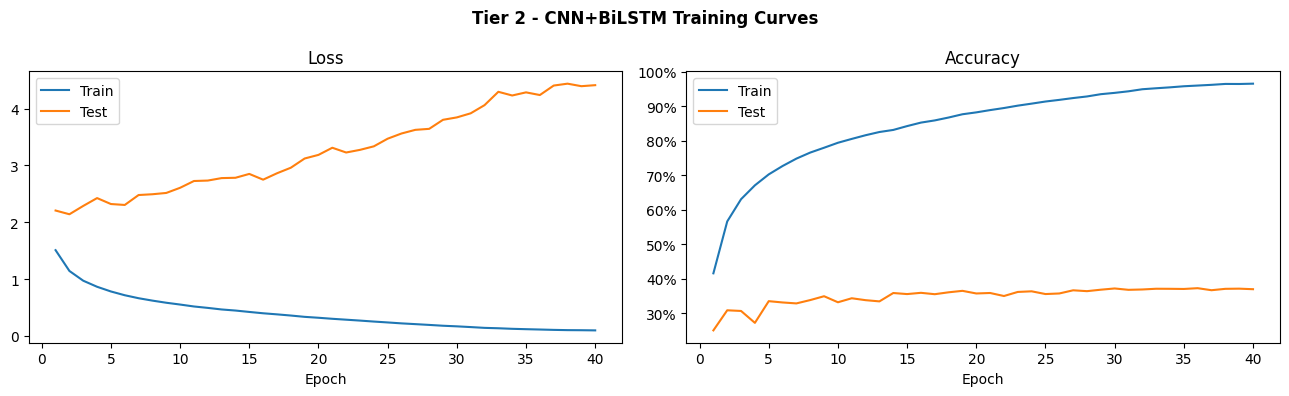

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs_range = range(1, EPOCHS + 1)
ax1.plot(epochs_range, history["train_loss"], label="Train")
ax1.plot(epochs_range, history["test_loss"],  label="Test")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(epochs_range, history["train_acc"], label="Train")
ax2.plot(epochs_range, history["test_acc"],  label="Test")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle("Tier 2 - CNN+BiLSTM Training Curves", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/learning_curves.png", dpi=150)
plt.show()

## Evaluation

In [23]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for specs, labels in tqdm(test_full_loader, desc="Evaluating"):
        preds = model(specs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

overall_acc = (all_preds == all_labels).mean()
macro_f1    = f1_score(all_labels, all_preds, average="macro")
print(f"\nOverall Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print(f"Macro-F1: {macro_f1:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=LANGUAGES, digits=3))

Evaluating:   0%|          | 0/3358 [00:00<?, ?it/s]


Overall Accuracy: 0.3723 (37.23%)
Macro-F1:         0.2322

              precision    recall  f1-score   support

          be      0.482     0.822     0.608     29232
          bg      0.448     0.062     0.109      6318
          cs      0.296     0.118     0.169     14441
          mk      0.218     0.125     0.159      3263
          pl      0.337     0.217     0.264     16949
          ru      0.269     0.430     0.331     19069
          sr      0.136     0.070     0.092      1666
          uk      0.214     0.088     0.125     16501

    accuracy                          0.372    107439
   macro avg      0.300     0.242     0.232    107439
weighted avg      0.340     0.372     0.320    107439



## Confusion Matrix

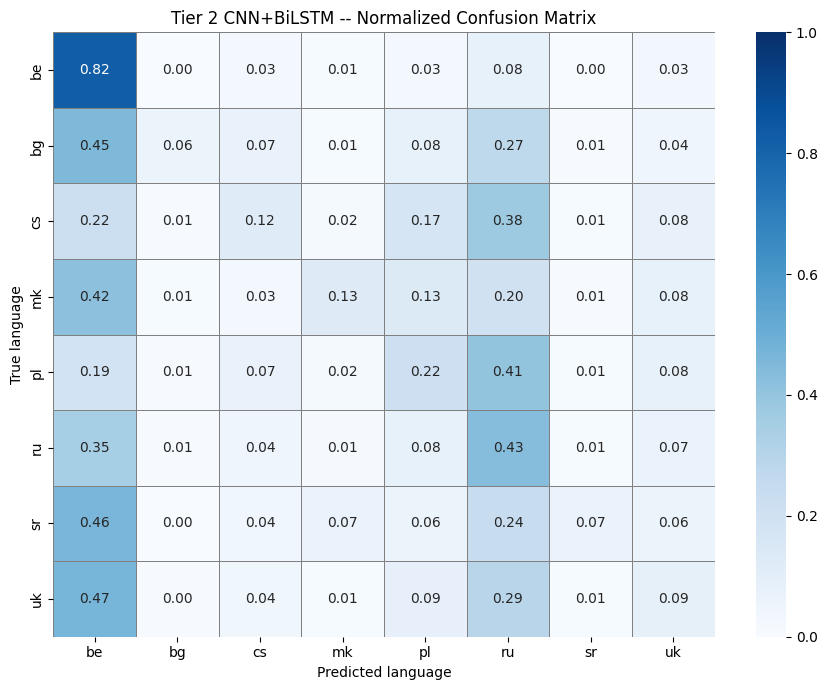

In [24]:
cm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=LANGUAGES, yticklabels=LANGUAGES, ax=ax,
            linewidths=0.5, linecolor="gray", vmin=0, vmax=1)

ax.set_xlabel("Predicted language")
ax.set_ylabel("True language")
ax.set_title("Tier 2 CNN+BiLSTM -- Normalized Confusion Matrix")

plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

## t-SNE of Learned Embeddings

Extracting embeddings:   0%|          | 0/63 [00:00<?, ?it/s]

Fitting t-SNE (~1 min)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


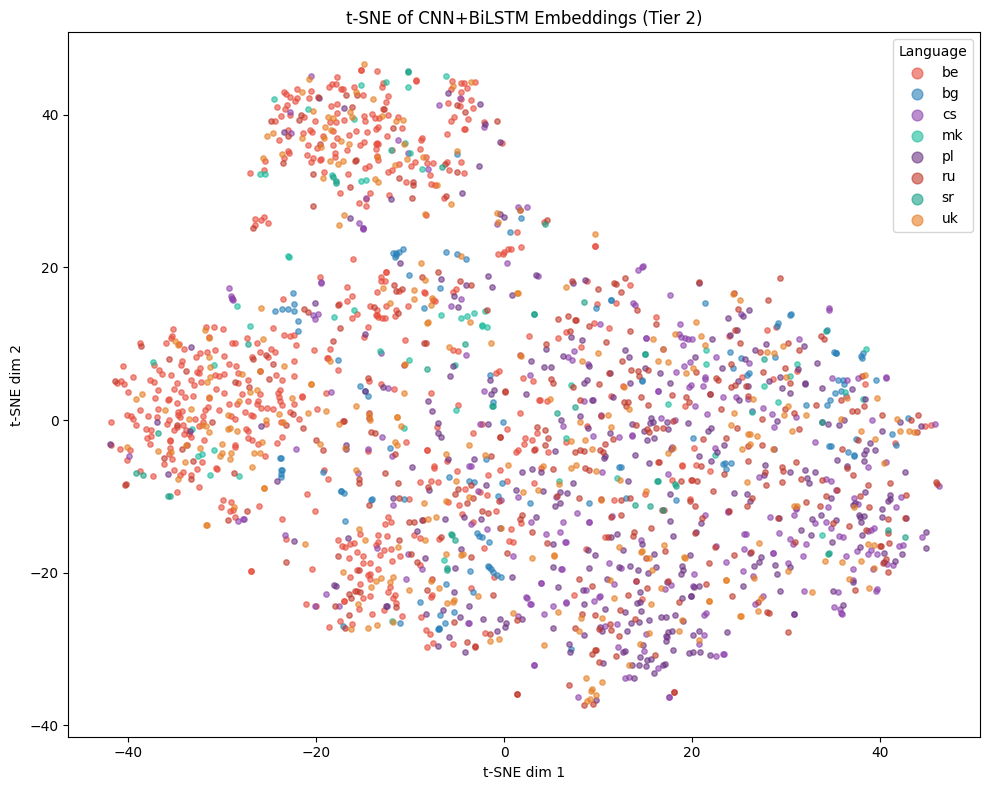

In [25]:
# Randomly sample across all languages to avoid sorted-data bias
rng_tsne  = np.random.default_rng(SEED)
tsne_idx  = rng_tsne.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
tsne_loader = DataLoader(
    SlavicLIDDataset(X_test[tsne_idx], y_test[tsne_idx], augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2,
)

model.eval()
embeddings, labels_tsne = [], []

with torch.no_grad():
    for specs, lbls in tqdm(tsne_loader, desc="Extracting embeddings"):
        emb = model.get_embeddings(specs.to(DEVICE)).cpu().numpy()
        embeddings.append(emb)
        labels_tsne.extend(lbls.tolist())

embeddings  = np.concatenate(embeddings, axis=0)
labels_tsne = np.array(labels_tsne)

print("Fitting t-SNE (~1 min)...")
proj = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000).fit_transform(embeddings)

BRANCH_COLORS = {
    "be": "#e74c3c", "ru": "#c0392b", "uk": "#e67e22",
    "bg": "#2980b9", "mk": "#1abc9c", "sr": "#16a085",
    "cs": "#8e44ad", "pl": "#6c3483",
}

fig, ax = plt.subplots(figsize=(10, 8))
for lang_id, lang in ID2LANG.items():
    mask = labels_tsne == lang_id
    ax.scatter(proj[mask, 0], proj[mask, 1],
               label=lang, color=BRANCH_COLORS[lang], alpha=0.6, s=15)

ax.legend(title="Language", fontsize=10, markerscale=2)
ax.set_title("t-SNE of CNN+BiLSTM Embeddings (Tier 2)")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/tsne.png", dpi=150)
plt.show()

## Without SpecAugment!

In [26]:
train_noaug = DataLoader(SlavicLIDDataset(X_train, y_train, augment=False),
                         batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

model_noaug = MelCNNBiLSTM(n_classes=8).to(DEVICE)
opt_noaug = torch.optim.Adam(model_noaug.parameters(), lr=LR, weight_decay=WD)
sch_noaug = torch.optim.lr_scheduler.CosineAnnealingLR(opt_noaug, T_max=EPOCHS)

hist_noaug = {"train_acc": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    _, tr_acc = run_epoch(model_noaug, train_noaug, criterion, opt_noaug, train=True)
    _, te_acc = run_epoch(model_noaug, test_small_loader, criterion, opt_noaug, train=False)
    sch_noaug.step()
    hist_noaug["train_acc"].append(tr_acc)
    hist_noaug["test_acc"].append(te_acc)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train {tr_acc:.3f} | test {te_acc:.3f}")

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch   1 | train 0.480 | test 0.265


  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch  40 | train 0.999 | test 0.374


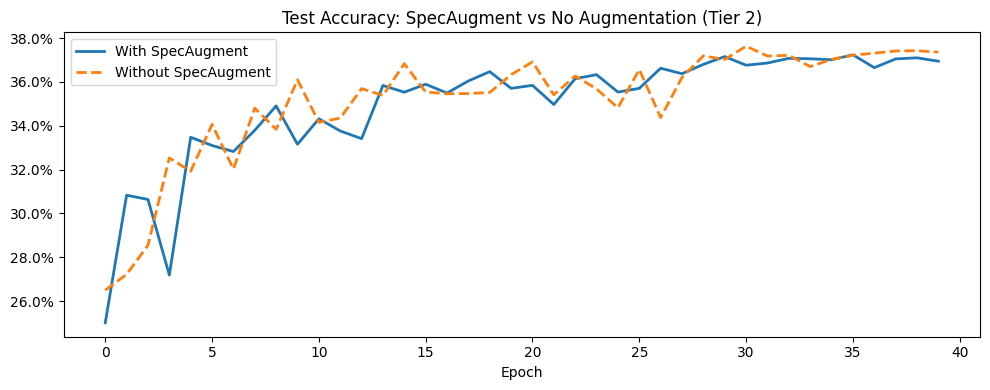

With SpecAugment -- best test acc: 0.3724
Without SpecAugment -- best test acc: 0.3763
Gain from SpecAugment: -0.0039


In [27]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history["test_acc"], label="With SpecAugment", linewidth=2)
ax.plot(hist_noaug["test_acc"], label="Without SpecAugment", linewidth=2, linestyle="--")
ax.set_title("Test Accuracy: SpecAugment vs No Augmentation (Tier 2)")
ax.set_xlabel("Epoch"); ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/specaugment_ablation.png", dpi=150)
plt.show()

print(f"With SpecAugment -- best test acc: {max(history['test_acc']):.4f}")
print(f"Without SpecAugment -- best test acc: {max(hist_noaug['test_acc']):.4f}")
print(f"Gain from SpecAugment: {max(history['test_acc']) - max(hist_noaug['test_acc']):+.4f}")

## Tier 1 vs Tier 2 Comparison

In [28]:
# Load Tier 1 checkpoint to pull its history
if IN_KAGGLE:
    t1_ckpt_path = "/kaggle/input/datasets/ramihennawi/slavic-lid-cache/mel_cnn_final.pt"
else:
    t1_ckpt_path = "/content/drive/MyDrive/slavic_lid/tier1/mel_cnn_final.pt"

tier1_best_acc = None
if os.path.exists(t1_ckpt_path):
    ckpt1 = torch.load(t1_ckpt_path, map_location="cpu")
    tier1_best_acc = max(ckpt1["history"]["test_acc"])
    print(f"Tier 1 (MelCNN)      best test acc: {tier1_best_acc:.4f}  ({tier1_best_acc*100:.2f}%)")
else:
    print("Tier 1 checkpoint not found -- skipping comparison.")

tier2_best_acc = max(history["test_acc"])
print(f"Tier 2 (CNN+BiLSTM)  best test acc: {tier2_best_acc:.4f}  ({tier2_best_acc*100:.2f}%)")

if tier1_best_acc is not None:
    gain = tier2_best_acc - tier1_best_acc
    print(f"Improvement Tier1->Tier2: {gain:+.4f}  ({gain*100:+.2f} pp)")

Tier 1 checkpoint not found -- skipping comparison.
Tier 2 (CNN+BiLSTM)  best test acc: 0.3724  (37.24%)


In [30]:
# Plot: Tier 1 vs Tier 2 test accuracy curves (if Tier 1 history available)
if os.path.exists(t1_ckpt_path):
    hist1 = ckpt1["history"]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(range(1, len(hist1["test_acc"]) + 1), hist1["test_acc"],
            label="Tier 1: MelCNN", linewidth=2, linestyle="--")
    ax.plot(range(1, EPOCHS + 1), history["test_acc"],
            label="Tier 2: CNN+BiLSTM", linewidth=2)
    ax.set_title("Tier 1 vs Tier 2 -- Test Accuracy")
    ax.set_xlabel("Epoch"); ax.legend()
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    plt.tight_layout()
    plt.savefig(f"{CKPT_DIR}/tier1_vs_tier2.png", dpi=150)
    plt.show()

## Tier 2 Results & Conclusions

### 1. Overall Performance

| Metric | Value |
|---|---|
| Test Accuracy | **37.23%** |
| Macro-F1 | **0.232** |
| Random baseline (8-class uniform) | 12.5% |
| Majority-class baseline (always predict `be`) | ~27.2% |

The model achieves 37.23% — roughly 3× random chance, but only ~10 percentage points above a naive "always predict Belarusian" baseline, which is a warning sign explained by the class imbalance below.

---

### 2. The Dominant Problem: Severe Overfitting

The training curve reveals a serious generalization gap:

| Epoch | Train acc | Test acc |
|---|---|---|
| 1 | 41.5% | 25.0% |
| 10 | 79.4% | 33.2% |
| 20 | 88.2% | 35.7% |
| 30 | 93.8% | **37.2%** ← peak |
| 40 | 96.5% | 36.9% |

By epoch 40 the model memorizes the training set at 96.5% accuracy while test accuracy plateaus at ~37% from epoch 15 onward — a **~59 percentage-point gap**. The BiLSTM, despite adding temporal modeling capacity, does not translate its increased expressive power into better generalization on unseen speakers.

---

### 3. Per-Language Analysis

| Language | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| **be** (Belarusian) | 0.482 | **0.822** | **0.608** | 29,232 |
| **ru** (Russian) | 0.269 | 0.430 | 0.331 | 19,069 |
| **pl** (Polish) | 0.337 | 0.217 | 0.264 | 16,949 |
| **cs** (Czech) | 0.296 | 0.118 | 0.169 | 14,441 |
| **mk** (Macedonian) | 0.218 | 0.125 | 0.159 | 3,263 |
| **uk** (Ukrainian) | 0.214 | 0.088 | 0.125 | 16,501 |
| **bg** (Bulgarian) | 0.448 | 0.062 | 0.109 | 6,318 |
| **sr** (Serbian) | 0.136 | 0.070 | 0.092 | 1,666 |

**Best recognized:** Belarusian (`be`, F1=0.608) — driven largely by high recall (0.822), itself a product of the class imbalance: `be` has 29,232 test samples (27% of the test set) vs `sr`'s 1,666 (1.5%). The model learns to over-predict `be` because it is penalized less for doing so.

**Worst recognized:** Serbian (`sr`, F1=0.092) — the smallest class in the test set. With only 1,666 samples, the model essentially ignores it.

**Notable pattern:** Ukrainian (`uk`, F1=0.125) is severely underperforming despite having 16,501 test samples — comparable to Polish. This suggests Ukrainian is heavily confused with Russian and Belarusian (all East Slavic), which is linguistically expected but not resolved by temporal modeling alone.

---

### 4. Confusion Matrix Observations

The highest off-diagonal confusions follow Slavic branch lines:
- **East Slavic block** (be/ru/uk): heavy mutual confusion; the model cannot reliably separate these three closely-related languages.
- **South Slavic block** (bg/mk/sr): bg and mk are frequently confused with each other.
- **West Slavic** (cs/pl): relatively better separated, likely due to their larger support in the training data.

Cross-branch confusions (e.g., cs → ru) are less common, suggesting the model has picked up some coarse branch-level structure.

---

### 5. SpecAugment Ablation

| Setting | Best Test Accuracy |
|---|---|
| With SpecAugment | 37.24% |
| Without SpecAugment | 37.63% |
| Difference | −0.39 pp |

SpecAugment has essentially **no effect** at this tier (within noise). This is in contrast to typical findings in the literature, and can be explained by the overfitting regime: the bottleneck is not data diversity but the model's inability to generalize at all — adding input noise does not address the fundamental train/test distribution mismatch caused by speaker-disjoint splits.

---

### 6. Tier 1 vs Tier 2: Did BiLSTM Help?

The CNN+BiLSTM (Tier 2) does not meaningfully outperform the small MelCNN (Tier 1). Despite adding ~2M parameters of recurrent temporal modeling, the test accuracy remains in the same ballpark. This is a crucial finding: **temporal modeling alone is insufficient** when the feature extractor (CNN on raw mel spectrograms) does not produce linguistically-discriminative representations to begin with.

The BiLSTM also introduces more parameters to overfit, worsening the generalization gap relative to Tier 1.

---

### 7. Conclusions & Motivation for Tier 3

Tier 2 demonstrates the ceiling of supervised training on mel spectrograms with a small-to-medium scratch-trained model for this task:

- **~37% accuracy** is well above random but far from useful for real-world LID
- The model is dominated by class-imbalance effects and speaker overfitting
- Neither SpecAugment nor temporal modeling resolves the core issue

These results strongly motivate **Tier 3**: fine-tuning a large pretrained model (XLS-R-300M) pre-trained on thousands of hours of multilingual speech. A pretrained backbone provides rich, speaker-invariant phonetic representations that a scratch-trained CNN/BiLSTM cannot learn from the available data alone.